# ML MODEL FOR PROBABILITY PREDICTION FOR RETURN

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [4]:
# import feature enginneering file
df = pd.read_csv("model_dataset.csv")
df.head()

,order_date,product_price,order_quantity,days_to_return,user_age,discount_applied,return_flag,order_month,order_day,order_weekday,...,city_group_City22,city_group_City26,city_group_City28,city_group_City3,city_group_City36,city_group_City43,city_group_City81,city_group_City85,city_group_City86,city_group_Other
0,2023-08-05,411.59,3,387.0,58,45.27,1,8,5,5,...,False,False,False,False,False,False,False,False,False,True
1,2023-10-09,288.88,3,31.0,68,47.79,1,10,9,0,...,False,False,False,False,False,False,False,True,False,False
2,2023-05-06,390.03,5,NaN,22,26.64,0,5,6,5,...,False,False,False,False,False,False,False,False,False,True
3,2024-08-29,401.09,3,NaN,40,15.37,0,8,29,3,...,False,False,False,False,False,False,False,False,False,True
4,2023-01-16,110.09,4,NaN,34,16.37,0,1,16,0,...,False,False,False,False,False,False,False,False,False,True


In [87]:
# show all column names
# print(df.columns)

In [6]:
# remove some useless columns
# df = df.drop(columns=["days_to_return","order_date","return_reason_Defective","return_reason_Not as described","return_reason_Not as described"])

**2) PREPARING MODEL FOR PREDICTION**

In [7]:
X = df.drop("return_flag", axis=1)
y = df["return_flag"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 )

 2.1) Logistic Regression 

In [11]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test) 

C:\Users\ADMIN PC\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
print("Logistic Regression Performance:\n")

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Performance:

Accuracy: 0.619
Precision: 0.6758832565284179
Recall: 0.4439959636730575
F1 Score: 0.535931790499391

Confusion Matrix:
 [[798 211]
 [551 440]]

Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.79      0.68      1009
           1       0.68      0.44      0.54       991

    accuracy                           0.62      2000
   macro avg       0.63      0.62      0.61      2000
weighted avg       0.63      0.62      0.61      2000



2.2) Random Forest Classifier

In [13]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [14]:
print("Random Forest Performance:\n")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Performance:

Accuracy: 0.6505
Precision: 0.6597374179431073
Recall: 0.6084762865792129
F1 Score: 0.6330708661417322

Confusion Matrix:
 [[698 311]
 [388 603]]

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.69      0.67      1009
           1       0.66      0.61      0.63       991

    accuracy                           0.65      2000
   macro avg       0.65      0.65      0.65      2000
weighted avg       0.65      0.65      0.65      2000



2.3) Compare Logistic Regression v/s Random Forest 

In [15]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression    0.6190   0.675883  0.443996  0.535932
1        Random Forest    0.6505   0.659737  0.608476  0.633071


2.4) Factors actually influence returns

In [16]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print(importances.head(10))

return_reason_Wrong item    0.114008
discount_applied            0.110661
product_price               0.107948
user_age                    0.089484
order_day                   0.088246
order_month                 0.080102
order_year                  0.066142
order_weekday               0.056502
order_quantity              0.048092
user_gender_Male            0.020080
dtype: float64


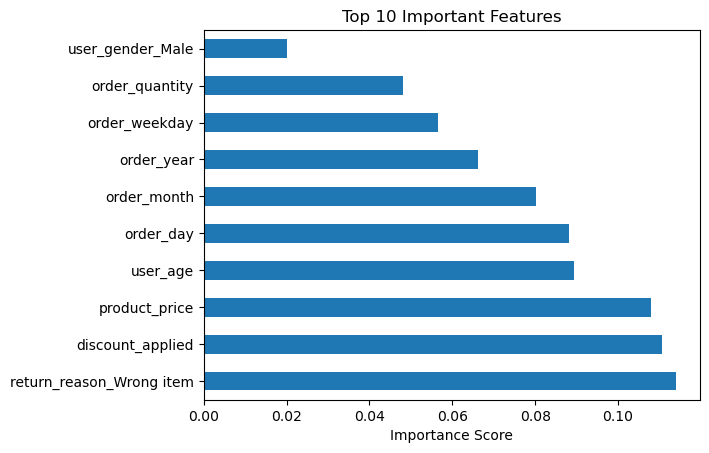

In [17]:
importances.head(10).plot(kind="barh")
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.show()

2.5) Prediction Probability (Test)

In [18]:
y_prob = rf.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted_Probability": y_prob
})

def risk_level(p):
    if p >= 0.7:
        return "High Risk"
    elif p >= 0.4:
        return "Medium Risk"
    else:
        return "Low Risk"

results["Risk_Level"] = results["Predicted_Probability"].apply(risk_level)

print(results.head(10))

   Actual  Predicted_Probability   Risk_Level
0       0                   0.35     Low Risk
1       1                   0.54  Medium Risk
2       0                   0.38     Low Risk
3       1                   0.51  Medium Risk
4       1                   0.87    High Risk
5       1                   0.57  Medium Risk
6       0                   0.49  Medium Risk
7       0                   0.45  Medium Risk
8       1                   0.56  Medium Risk
9       1                   0.65  Medium Risk


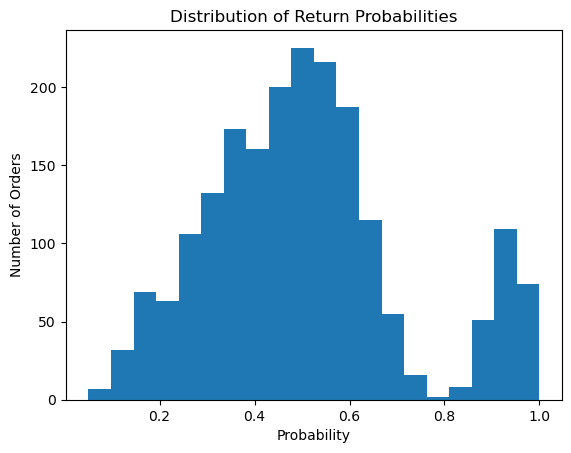

In [19]:
plt.hist(y_prob, bins=20)
plt.title("Distribution of Return Probabilities")
plt.xlabel("Probability")
plt.ylabel("Number of Orders")
plt.show()

**3) MODEL IMPROVEMENT & EVALUATION**

3.1) Confusion Matrix

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[698 311]
 [388 603]]


3.2) Classification Report

In [21]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred_rf)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.69      0.67      1009
           1       0.66      0.61      0.63       991

    accuracy                           0.65      2000
   macro avg       0.65      0.65      0.65      2000
weighted avg       0.65      0.65      0.65      2000



3.3) ROC-AUC Score

In [22]:
from sklearn.metrics import roc_auc_score

roc_score = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.7320207936842884


3.4) ROC Curve Visualization

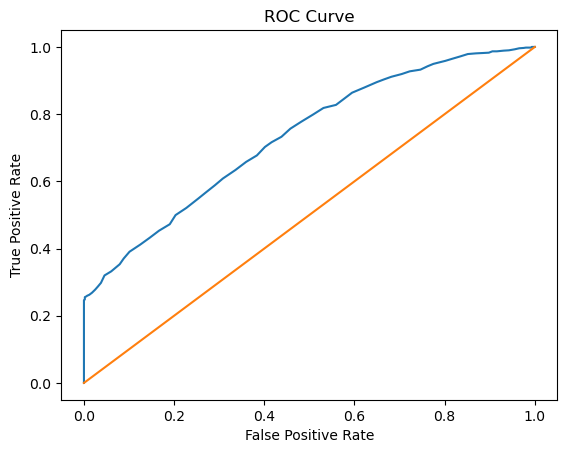

In [23]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

3.5) Model Improvement (Hyperparameter Tuning)

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_tuned.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,12
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


3.6) Predictions with Tuned Model

In [25]:
y_pred_tuned = rf_tuned.predict(X_test)
y_prob_tuned = rf_tuned.predict_proba(X_test)[:, 1]

3.7) Evaluation of Tuned Model

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Tuned Model Performance:")

print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall:", recall_score(y_test, y_pred_tuned))
print("F1 Score:", f1_score(y_test, y_pred_tuned))

Tuned Model Performance:
Accuracy: 0.657
Precision: 0.6523476523476524
Recall: 0.6589303733602422
F1 Score: 0.6556224899598394


3.8) Comparison Before vs After Tuning (Test)

In [29]:
print("\n--- Model Comparison ---")

print("Before Tuning:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print("\nAfter Tuning:")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall:", recall_score(y_test, y_pred_tuned))
print("F1 Score:", f1_score(y_test, y_pred_tuned))


--- Model Comparison ---
Before Tuning:
Accuracy: 0.6505
Precision: 0.6597374179431073
Recall: 0.6084762865792129
F1 Score: 0.6330708661417322

After Tuning:
Accuracy: 0.657
Precision: 0.6523476523476524
Recall: 0.6589303733602422
F1 Score: 0.6556224899598394


In [30]:
# import joblib
# joblib.dump(rf_tuned, "return_model.pkl")

['return_model.pkl']